# Sector-Neutral Label 实验

**研究问题**：把标签从「个股收益 − SPY 收益」换成「个股收益 − 同行业等权均值收益」，
是否能提升 OOS Rank IC？

**基准**（research_v2 Section 12，H=5 + excess_ret）：
mean IC = 0.0197, HAC t = 1.603, p = 0.054

**实验配置**：完全相同的特征 pipeline（含 excess_ret primitives），只换 label。

流程：
1. 加载数据 + 行业分类
2. 构建 sector-neutral 标签
3. 标签质量分析（分布 vs benchmark-relative）
4. 复用特征，构建 H=5 数据集
5. Walk-forward CatBoost
6. OOS 结果对比

In [13]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sp500_relative_alpha.catboost_models import CatBoostRegressorConfig, CatBoostRegressorPredictor
from sp500_relative_alpha.daily_data_loader import ROUND1_SNAPSHOT_MANIFEST, load_round1_daily_ohlcv
from sp500_relative_alpha.feature_transforms import CrossCombinationSpec, TransformConfig
from sp500_relative_alpha.folds import (
    build_round1_walk_forward_folds,
    fold_period_mask,
    validate_fold_label_windows,
)
from sp500_relative_alpha.metrics import RankICConfig, evaluate_oos_rank_ic
from sp500_relative_alpha.modeling import (
    WalkForwardPredictionConfig,
    _select_top_features_by_ic,
    run_walk_forward_predictions,
)
from sp500_relative_alpha.research_dataset import build_v2_research_dataset
from sp500_relative_alpha.sector_data import build_sector_map

HORIZON = 5
EXCLUDED_SYMBOLS = ("HUBB",)
SECTOR_NEUTRAL_LABEL = "sector_relative_open_to_open_return"

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

## 1. 数据加载

In [2]:
manifest = pd.read_csv(ROUND1_SNAPSHOT_MANIFEST)
load_symbols = [s for s in manifest["symbol"].tolist() if s not in EXCLUDED_SYMBOLS]

daily_bars = load_round1_daily_ohlcv(symbols=load_symbols)
print(f"rows={len(daily_bars):,}  symbols={daily_bars['symbol'].nunique()}")

# 行业分类（从缓存读，无需重新拉取）
sector_map = build_sector_map(load_symbols)
sector_series = pd.Series(sector_map)
print(f"\nSector coverage: {(sector_series != 'Unknown').sum()}/{len(sector_series)} symbols")
print(sector_series.value_counts().to_string())

rows=1,375,565  symbols=503

Sector coverage: 503/503 symbols
Technology                84
Industrials               73
Financial Services        70
Healthcare                58
Consumer Cyclical         54
Consumer Defensive        35
Utilities                 31
Real Estate               31
Communication Services    24
Energy                    22
Basic Materials           20
Benchmark                  1


## 2. 构建 Sector-Neutral 标签

```
sector_relative_return[stock, t] = asset_return[stock, t] - mean(asset_return[sector_peers, t])
```

entry = signal_date+1 open, exit = signal_date+1+H open（与 benchmark-relative 完全相同的时间结构）。

In [3]:
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels

# Step 1: 拿到原始标签（含 asset_open_to_open_return）
base_labels = build_round1_benchmark_relative_open_to_open_labels(daily_bars, horizons=[HORIZON])
base_labels = base_labels[base_labels["horizon"] == HORIZON].copy()

# Step 2: 给每个 symbol 打上 sector 标签
base_labels["sector"] = base_labels["symbol"].map(sector_map).fillna("Unknown")

# Step 3: 计算每个 sector 在每个 signal_date 的等权均值收益
sector_mean = (
    base_labels
    .groupby(["signal_date", "sector"])["asset_open_to_open_return"]
    .transform("mean")
)

# Step 4: sector-neutral 超额收益
base_labels[SECTOR_NEUTRAL_LABEL] = base_labels["asset_open_to_open_return"] - sector_mean

print(f"Labels: {len(base_labels):,} rows")
print(f"\nLabel 分布对比:")
for col in ["benchmark_relative_open_to_open_return", SECTOR_NEUTRAL_LABEL]:
    s = base_labels[col].dropna()
    print(f"  {col}:")
    print(f"    mean={s.mean():.5f}  std={s.std():.4f}  |IC_noise|: std smaller = cleaner signal")

Labels: 1,225,807 rows

Label 分布对比:
  benchmark_relative_open_to_open_return:
    mean=0.00053  std=0.0401  |IC_noise|: std smaller = cleaner signal
  sector_relative_open_to_open_return:
    mean=-0.00000  std=0.0360  |IC_noise|: std smaller = cleaner signal


## 3. 标签质量分析

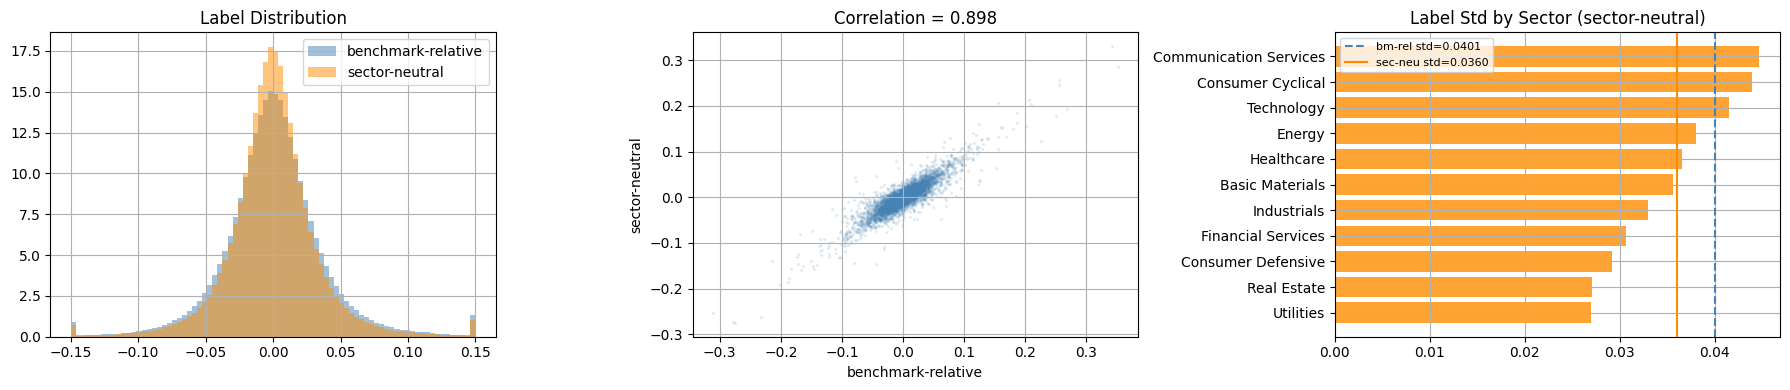

benchmark-relative std : 0.04006
sector-neutral std     : 0.03599
SNR improvement        : 11.3% smaller std


In [4]:
bm_label = "benchmark_relative_open_to_open_return"

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 分布对比
for col, color, label in [
    (bm_label, "steelblue", "benchmark-relative"),
    (SECTOR_NEUTRAL_LABEL, "darkorange", "sector-neutral"),
]:
    axes[0].hist(base_labels[col].clip(-0.15, 0.15), bins=80,
                 alpha=0.5, color=color, label=label, density=True)
axes[0].set_title("Label Distribution")
axes[0].legend()

# 两个标签的相关性（散点，抽样）
sample = base_labels.sample(5000, random_state=42)
axes[1].scatter(sample[bm_label], sample[SECTOR_NEUTRAL_LABEL], alpha=0.1, s=2, color="steelblue")
corr = base_labels[[bm_label, SECTOR_NEUTRAL_LABEL]].corr().iloc[0, 1]
axes[1].set_title(f"Correlation = {corr:.3f}")
axes[1].set_xlabel("benchmark-relative")
axes[1].set_ylabel("sector-neutral")

# 每个 sector 的标签 std（sector-neutral 应该更小）
sector_std = base_labels.groupby("sector")[SECTOR_NEUTRAL_LABEL].std().sort_values()
bm_std_total = base_labels[bm_label].std()
sn_std_total = base_labels[SECTOR_NEUTRAL_LABEL].std()
axes[2].barh(sector_std.index, sector_std.values, color="darkorange", alpha=0.8)
axes[2].axvline(bm_std_total, color="steelblue", lw=1.5, linestyle="--", label=f"bm-rel std={bm_std_total:.4f}")
axes[2].axvline(sn_std_total, color="darkorange", lw=1.5, linestyle="-", label=f"sec-neu std={sn_std_total:.4f}")
axes[2].set_title("Label Std by Sector (sector-neutral)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"benchmark-relative std : {bm_std_total:.5f}")
print(f"sector-neutral std     : {sn_std_total:.5f}")
print(f"SNR improvement        : {bm_std_total/sn_std_total - 1:.1%} smaller std")

## 4. 特征复用，构建 H=5 数据集

In [5]:
CROSS_COMBINATIONS = (
    CrossCombinationSpec("ret_20d", "volume_ratio_20d", "mul", "ret20d_x_volr20d"),
    CrossCombinationSpec("ret_60d", "volume_ratio_60d", "mul", "ret60d_x_volr60d"),
    CrossCombinationSpec("ret_20d", "high_low_range",   "sub", "ret20d_sub_hlr"),
    CrossCombinationSpec("ret_60d", "high_low_range",   "sub", "ret60d_sub_hlr"),
    CrossCombinationSpec("ret_5d",  "ret_60d",          "sub", "ret5d_sub_ret60d"),
    CrossCombinationSpec("ret_20d", "ret_252d",         "sub", "ret20d_sub_ret252d"),
    CrossCombinationSpec("close_position", "volume_ratio_20d", "mul", "closepos_x_volr20d"),
)
TRANSFORM_CONFIG = TransformConfig(
    keep_identity=True,
    apply_cs_rank=True,
    ts_zscore_windows=(20, 60, 120),
    ts_change_windows=(5, 20, 60),
    apply_second_order=True,
    cross_combinations=CROSS_COMBINATIONS,
    output_prefix="feat_",
)

# 构建完整特征（含 excess_ret primitives，与 research_v2 v3 完全一致）
print("Building v3 feature dataset (H=5)...")
dataset = build_v2_research_dataset(
    daily_bars,
    horizons=[HORIZON],
    transform_config=TRANSFORM_CONFIG,
)
feat_df = dataset[dataset["horizon"] == HORIZON][["signal_date", "symbol"] +
    sorted(c for c in dataset.columns if c.startswith("feat_"))].copy()
feat_cols = sorted(c for c in feat_df.columns if c.startswith("feat_"))
print(f"  features: {len(feat_cols)}")

# 拼 sector-neutral 标签 + 特征
samples = base_labels.merge(feat_df, on=["signal_date", "symbol"], how="left", validate="many_to_one")
samples = samples.reset_index(drop=True)
print(f"  samples: {len(samples):,}  label_nan: {samples[SECTOR_NEUTRAL_LABEL].isna().mean():.2%}")

Building v3 feature dataset (H=5)...


/Users/hsy/Work/Invest/sp500_relative_alpha/feature_transforms.py:226: RuntimeWarning: invalid value encountered in subtract
  result[window:] = (mat[window:] - mat[:-window]).astype(np.float32)


  features: 1547
  samples: 1,225,807  label_nan: 0.00%


## 5. Walk-Forward CatBoost（Sector-Neutral Label）

In [6]:
signal_dates = samples["signal_date"].drop_duplicates()
folds = build_round1_walk_forward_folds(signal_dates)
validate_fold_label_windows(
    samples, folds,
    signal_date_column="signal_date",
    entry_date_column="entry_date",
    exit_date_column="exit_date",
)
print(f"Folds: {len(folds)}, label window validation passed")
for f in folds:
    print(f"  {f.fold_id}: train [{f.train_start.date()}→{f.train_end.date()}]  "
          f"test [{f.test_start.date()}→{f.test_end.date()}]")

cb_config = CatBoostRegressorConfig()
prediction_config = WalkForwardPredictionConfig(
    label_column=SECTOR_NEUTRAL_LABEL,
    feature_prefix="feat_",
    n_top_features=200,
)

print(f"\nRunning walk-forward (H={HORIZON}, sector-neutral label)...")
predictions = run_walk_forward_predictions(
    samples,
    folds,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=prediction_config,
)
print(f"Prediction rows: {len(predictions):,}")

Folds: 5, label window validation passed
  fold_001: train [2015-12-31→2020-01-02]  test [2020-03-31→2020-09-28]
  fold_002: train [2015-12-31→2020-09-28]  test [2020-12-23→2021-06-24]
  fold_003: train [2015-12-31→2021-06-24]  test [2021-09-21→2022-03-21]
  fold_004: train [2015-12-31→2022-03-21]  test [2022-06-16→2022-12-14]
  fold_005: train [2015-12-31→2022-12-14]  test [2023-03-15→2023-09-13]

Running walk-forward (H=5, sector-neutral label)...
Prediction rows: 310,547


## 6. OOS 结果

注意：模型用 sector-neutral label 训练，但我们同时用两种 label 评估 Rank IC，
观察 sector-neutral 打分是否在两种维度都有提升。

In [8]:
# 评估1：sector-neutral IC（先去掉旧的 bm 列，再 rename，避免重名列）
pred_sn = (
    predictions
    .drop(columns=["benchmark_relative_open_to_open_return"])
    .rename(columns={SECTOR_NEUTRAL_LABEL: "benchmark_relative_open_to_open_return"})
)
panel_sn, fold_summary_sn, horizon_summary_sn = evaluate_oos_rank_ic(pred_sn, folds, RankICConfig())
row_sn = horizon_summary_sn[horizon_summary_sn["horizon"] == HORIZON].iloc[0]

# 评估2：benchmark-relative IC（去掉 sector-neutral 列，保留原始 bm 列）
pred_bm = predictions.drop(columns=[SECTOR_NEUTRAL_LABEL])
panel_bm, fold_summary_bm, horizon_summary_bm = evaluate_oos_rank_ic(pred_bm, folds, RankICConfig())
row_bm = horizon_summary_bm[horizon_summary_bm["horizon"] == HORIZON].iloc[0]

print("=== Fold-level Rank IC ===")
print(f"{'fold_id':10s}  {'sec-neutral IC':>15s}  {'bm-relative IC':>15s}")
for (_, rsn), (_, rbm) in zip(fold_summary_sn.iterrows(), fold_summary_bm.iterrows()):
    print(f"{rsn['fold_id']:10s}  {rsn['mean_rank_ic']:15.4f}  {rbm['mean_rank_ic']:15.4f}")

print(f"\n=== Overall ===")
print(f"{'':30s}  {'sec-neutral':>12s}  {'bm-relative':>12s}")
print(f"{'mean Rank IC':30s}  {row_sn['mean_rank_ic']:12.4f}  {row_bm['mean_rank_ic']:12.4f}")
print(f"{'ICIR':30s}  {row_sn['icir']:12.3f}  {row_bm['icir']:12.3f}")
print(f"{'HAC t-stat':30s}  {row_sn['hac_t_stat']:12.3f}  {row_bm['hac_t_stat']:12.3f}")
print(f"{'p (one-sided)':30s}  {row_sn['p_value_one_sided']:12.4f}  {row_bm['p_value_one_sided']:12.4f}")

=== Fold-level Rank IC ===
fold_id      sec-neutral IC   bm-relative IC
fold_001             0.0524           0.0485
fold_002             0.0085           0.0112
fold_003            -0.0082          -0.0100
fold_004             0.0038           0.0037
fold_005             0.0216           0.0313

=== Overall ===
                                 sec-neutral   bm-relative
mean Rank IC                          0.0156        0.0170
ICIR                                   0.126         0.108
HAC t-stat                             1.850         1.597
p (one-sided)                         0.0322        0.0551


=== 对比汇总 ===
                         model  mean_ic     icir   t_stat        p
H=5 v3 benchmark-relative (基准) 0.019700 0.111000 1.603000 0.054000
   H=5 v3 sector-neutral (本实验) 0.015629 0.126215 1.849995 0.032157

=== Per-fold IC 对比 ===
fold_id      bm-relative   sec-neutral     diff
fold_001          0.0520        0.0524  +0.0004
fold_002         -0.0020        0.0085  +0.0105
fold_003         -0.0026       -0.0082  -0.0056
fold_004          0.0217        0.0038  -0.0179
fold_005          0.0295        0.0216  -0.0079


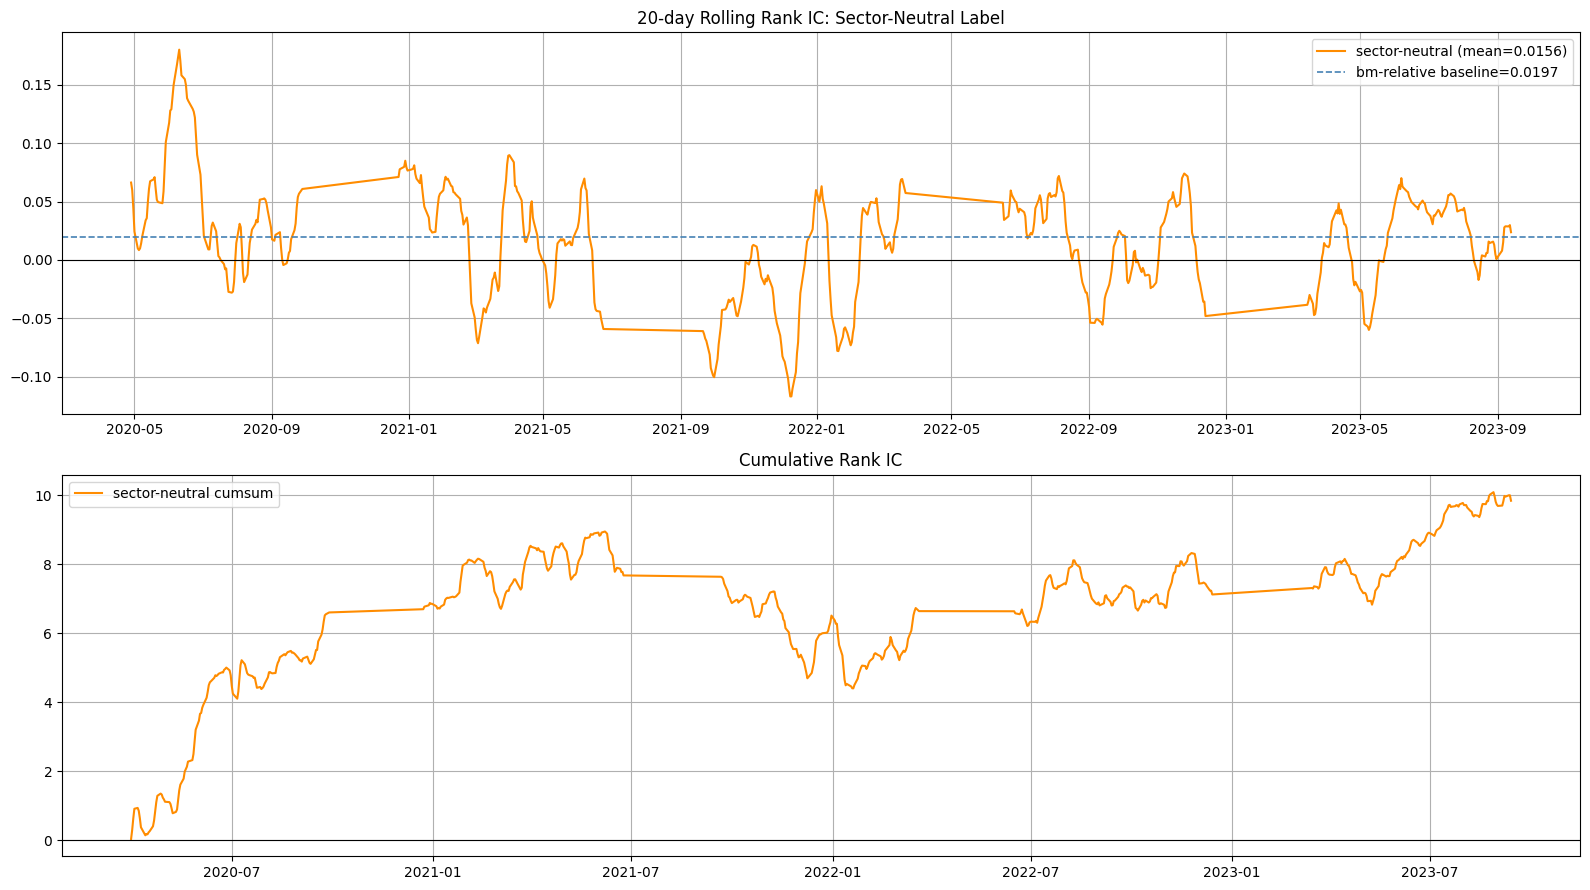

In [ ]:
# 与 research_v2 基准对比
BASELINE = {
    "mean_rank_ic": 0.0197, "icir": 0.111,
    "hac_t_stat": 1.603, "p_value_one_sided": 0.054,
}
BASELINE_FOLDS = [0.0520, -0.0020, -0.0026, 0.0217, 0.0295]  # v3 H=5 benchmark-relative

print("=== 对比汇总 ===")
comparison = pd.DataFrame([
    {"model": "H=5 v3 benchmark-relative (基准)",
     "mean_ic": BASELINE["mean_rank_ic"], "icir": BASELINE["icir"],
     "t_stat": BASELINE["hac_t_stat"], "p": BASELINE["p_value_one_sided"]},
    {"model": "H=5 v3 sector-neutral (本实验)",
     "mean_ic": row_sn["mean_rank_ic"], "icir": row_sn["icir"],
     "t_stat": row_sn["hac_t_stat"], "p": row_sn["p_value_one_sided"]},
])
print(comparison.to_string(index=False))

print("\n=== Per-fold IC 对比 ===")
print(f"{'fold_id':10s}  {'bm-relative':>12s}  {'sec-neutral':>12s}  {'diff':>7s}")
for i, (_, row) in enumerate(fold_summary_sn.iterrows()):
    diff = row["mean_rank_ic"] - BASELINE_FOLDS[i]
    print(f"{row['fold_id']:10s}  {BASELINE_FOLDS[i]:12.4f}  {row['mean_rank_ic']:12.4f}  {diff:+.4f}")

# 时序图
ic_sn = panel_sn[panel_sn["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].plot(ic_sn.index, ic_sn.rolling(20).mean(),
             label=f"sector-neutral (mean={ic_sn.mean():.4f})", color="darkorange")
axes[0].axhline(BASELINE["mean_rank_ic"], color="steelblue", lw=1.2,
                linestyle="--", label=f"bm-relative baseline={BASELINE['mean_rank_ic']:.4f}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("20-day Rolling Rank IC: Sector-Neutral Label")
axes[0].legend()

axes[1].plot(ic_sn.index, ic_sn.cumsum(), color="darkorange",
             label="sector-neutral cumsum")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Cumulative Rank IC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Sample Weight 时间衰减实验

**动机**：expanding window 里越早的样本对当前 regime 的代表性越低。
用指数衰减权重让近期样本影响更大，测试能否改善 regime adaptation。

**实现**：`weight_i = exp(-log(2) / half_life * days_ago_i)`
`half_life = 252`（约1年）时，1年前的样本权重 = 0.5，3年前 ≈ 0.125。

In [16]:
import importlib, sp500_relative_alpha.catboost_models as _cb_mod
importlib.reload(_cb_mod)
from sp500_relative_alpha.catboost_models import CatBoostRegressorConfig, CatBoostRegressorPredictor
from sp500_relative_alpha.modeling import WalkForwardPredictionConfig, run_walk_forward_predictions

HALF_LIFE = 252

cb_config_td = CatBoostRegressorConfig(
    iterations=500, depth=6, learning_rate=0.03,
    l2_leaf_reg=3.0, min_data_in_leaf=200,
    sample_weight_half_life_days=HALF_LIFE,
)
wf_config_td = WalkForwardPredictionConfig(
    label_column=SECTOR_NEUTRAL_LABEL,
    feature_prefix="feat_",
    n_top_features=200,
)

print(f"Running walk-forward with time decay (half_life={HALF_LIFE}d)...")
predictions_td = run_walk_forward_predictions(
    samples,
    folds,
    lambda: CatBoostRegressorPredictor(cb_config_td),
    config=wf_config_td,
)
print(f"Prediction rows: {len(predictions_td):,}")

# Evaluate sector-neutral IC
pred_td = (
    predictions_td
    .drop(columns=["benchmark_relative_open_to_open_return"])
    .rename(columns={SECTOR_NEUTRAL_LABEL: "benchmark_relative_open_to_open_return"})
)
panel_td, fold_summary_td, horizon_summary_td = evaluate_oos_rank_ic(
    pred_td, folds, RankICConfig()
)
row_td = horizon_summary_td[horizon_summary_td["horizon"] == HORIZON].iloc[0]

# Compare
print(f"\n=== H=5 Sector-Neutral: uniform vs time-decay (half_life={HALF_LIFE}d) ===")
print(f"{'':30s}  {'uniform':>10s}  {'decay-'+str(HALF_LIFE)+'d':>12s}")
for metric, key in [
    ("mean Rank IC", "mean_rank_ic"),
    ("ICIR", "icir"),
    ("HAC t-stat", "hac_t_stat"),
    ("p (one-sided)", "p_value_one_sided"),
]:
    print(f"{metric:30s}  {row_sn[key]:10.4f}  {row_td[key]:12.4f}")

print("\n=== Per-fold IC ===")
print(f"{'fold_id':10s}  {'uniform IC':>10s}  {'decay IC':>10s}  {'diff':>7s}")
for (_, r_uni), (_, r_td_row) in zip(fold_summary_sn.iterrows(), fold_summary_td.iterrows()):
    diff = r_td_row["mean_rank_ic"] - r_uni["mean_rank_ic"]
    print(f"{r_td_row['fold_id']:10s}  {r_uni['mean_rank_ic']:10.4f}  {r_td_row['mean_rank_ic']:10.4f}  {diff:+.4f}")


Running walk-forward with time decay (half_life=252d)...
Prediction rows: 310,547

=== H=5 Sector-Neutral: uniform vs time-decay (half_life=252d) ===
                                   uniform    decay-252d
mean Rank IC                        0.0156        0.0011
ICIR                                0.1262        0.0101
HAC t-stat                          1.8500        0.1598
p (one-sided)                       0.0322        0.4365

=== Per-fold IC ===
fold_id     uniform IC    decay IC     diff
fold_001        0.0524      0.0365  -0.0159
fold_002        0.0085     -0.0007  -0.0093
fold_003       -0.0082     -0.0165  -0.0083
fold_004        0.0038     -0.0038  -0.0076
fold_005        0.0216     -0.0101  -0.0317
